In [1]:
import datetime
import pickle
import polars as pl
from donations import ml_utils
import mlflow
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error
from donations import constants
import numpy as np
import optuna
from optuna.integration.mlflow import MLflowCallback

In [2]:
with open("tmp/df_all.pkl", "rb") as file:
    df_all = pickle.load(file)

In [3]:
df_all = df_all.with_columns([
    pl.col("date").dt.weekday().alias("weekday"),
    pl.col("date").dt.month().alias("month"),
    pl.col("date").dt.ordinal_day().alias("day_of_year")   
])

df_all.head(8)

date,a,b,o,ab,all,is_religion_or_culture_holiday,is_other_holiday,is_low_donation_holiday,is_high_donation_holiday,weekday,month,day_of_year
date,i64,i64,i64,i64,i64,u8,u8,u8,u8,i8,i8,i16
2006-01-01,152,139,194,40,525,0,0,0,0,7,1,1
2006-01-02,53,43,112,19,227,0,0,0,0,1,1,2
2006-01-03,29,21,56,6,112,0,0,0,0,2,1,3
2006-01-04,92,98,165,36,391,0,0,0,0,3,1,4
2006-01-05,149,198,193,42,582,0,0,0,0,4,1,5
2006-01-06,94,77,126,27,324,0,0,0,0,5,1,6
2006-01-07,29,28,48,13,118,0,0,0,0,6,1,7
2006-01-08,218,212,314,51,795,0,0,0,0,7,1,8


In [4]:
for lag in range(1, constants.WINDOW_SIZE+1):
    df_all = df_all.with_columns(
        pl.col("all").shift(lag).alias(f"all_lag_{lag}")
    )

df_all = df_all.drop_nulls()

In [5]:
df_all

date,a,b,o,ab,all,is_religion_or_culture_holiday,is_other_holiday,is_low_donation_holiday,is_high_donation_holiday,weekday,month,day_of_year,all_lag_1,all_lag_2,all_lag_3,all_lag_4,all_lag_5,all_lag_6,all_lag_7
date,i64,i64,i64,i64,i64,u8,u8,u8,u8,i8,i8,i16,i64,i64,i64,i64,i64,i64,i64
2006-01-08,218,212,314,51,795,0,0,0,0,7,1,8,118,324,582,391,112,227,525
2006-01-09,83,95,151,17,346,0,0,0,0,1,1,9,795,118,324,582,391,112,227
2006-01-10,1,0,1,0,2,1,0,1,0,2,1,10,346,795,118,324,582,391,112
2006-01-11,128,111,179,30,448,0,0,0,0,3,1,11,2,346,795,118,324,582,391
2006-01-12,211,236,316,42,805,0,0,0,0,4,1,12,448,2,346,795,118,324,582
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-06-01,556,589,1056,65,2266,0,0,0,0,7,6,152,1600,946,1379,1439,1181,1024,3215
2025-06-02,442,509,781,60,1792,0,1,0,0,1,6,153,2266,1600,946,1379,1439,1181,1024
2025-06-03,282,293,460,49,1084,0,0,0,0,2,6,154,1792,2266,1600,946,1379,1439,1181


In [6]:
X_seq = df_all.select([f"all_lag_{lag}" for lag in range(1, constants.WINDOW_SIZE+1)]).to_numpy().reshape(-1, constants.WINDOW_SIZE, 1)
X_features = df_all.select(["weekday", "month", "day_of_year", "is_religion_or_culture_holiday", "is_other_holiday", "is_low_donation_holiday", "is_high_donation_holiday"]).to_numpy()
y = df_all['all'].to_numpy()

In [7]:
# Set up scalers 
from sklearn.preprocessing import RobustScaler

y_scaler = RobustScaler()
X_scaler = RobustScaler()

In [8]:
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()
X_features_scaled = X_scaler.fit_transform(X_features)
X_seq_scaled = y_scaler.transform(X_seq.reshape(-1, 1)).reshape(-1, constants.WINDOW_SIZE, 1)

In [9]:
with open('shared/x_scaler.pkl', 'wb') as file:
    pickle.dump(X_scaler, file)
    
with open('shared/y_scaler.pkl', 'wb') as file:
    pickle.dump(y_scaler, file)

In [10]:
X_seq_train, X_seq_val, X_seq_test, X_features_train, X_features_val, X_features_test, y_train, y_val, y_test = ml_utils.train_val_test_split_feature_data(
    X_seq_scaled,
    X_features_scaled,
    y_scaled,
    constants.TRAIN_FRAC,
    constants.VAL_FRAC
)

In [11]:
experiment_name = f"{constants.EXPERIMENT_NAME}_{datetime.datetime.now().strftime('%Y%m%d')}"
experiment_id = ml_utils.get_or_create_mlflow_experiment(experiment_name)
mlflow.set_experiment(experiment_name)
mlflow_callback = MLflowCallback(
    tracking_uri = mlflow.get_tracking_uri(),
    metric_name = "val_loss"
)

In [12]:
def objective(trial):
    seq_type = trial.suggest_categorical("seq_type", ["LSTM", "SimpleRNN", "GRU"])
    seq_units = trial.suggest_int("seq_units", 12, 48)
    dense_units = trial.suggest_int("dense_units", 4, 12)
    activation = trial.suggest_categorical("activation", ["tanh", "relu", "mish"])
    optimizer = trial.suggest_categorical("optimizer", ["adam", "rmsprop"])
    dropout = trial.suggest_float("dropout", 0.01, 0.1)
    learning_rate = trial.suggest_float("learning_rate", 0.0001, 0.1, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    
    ml_utils.run_experiment(
        X_seq_train, X_features_train, y_train,
        X_seq_val, X_features_val, y_val,
        seq_type=seq_type,
        seq_units=seq_units,
        dense_units=dense_units,
        activation=activation,
        optimizer=optimizer,
        dropout=dropout,
        learning_rate=learning_rate,
        batch_size=batch_size,
        experiment_id=experiment_id
    )
    
    runs = mlflow.search_runs(experiment_ids=[experiment_id], order_by=["start_time DESC"])
    val_loss = runs.iloc[0]["metrics.val_loss"]
    return val_loss

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=constants.N_TRIALS, callbacks=[mlflow_callback])

[I 2025-07-13 14:22:33,116] A new study created in memory with name: no-name-fc65b0ce-2b02-4750-9753-47e0fbf90669


[I 2025-07-13 14:23:14,091] Trial 0 finished with value: 0.22651517391204834 and parameters: {'seq_type': 'GRU', 'seq_units': 41, 'dense_units': 5, 'activation': 'mish', 'optimizer': 'rmsprop', 'dropout': 0.022401517929541565, 'learning_rate': 0.0015036118227608791, 'batch_size': 128}. Best is trial 0 with value: 0.22651517391204834.
2025/07/13 14:23:14 INFO mlflow.tracking.fluent: Experiment with name 'no-name-fc65b0ce-2b02-4750-9753-47e0fbf90669' does not exist. Creating a new experiment.


Validation Loss: 0.22651512920856476, Validation MAE: 0.3230602741241455


[I 2025-07-13 14:24:45,977] Trial 1 finished with value: 0.2235371619462967 and parameters: {'seq_type': 'LSTM', 'seq_units': 46, 'dense_units': 8, 'activation': 'mish', 'optimizer': 'adam', 'dropout': 0.035522714033435036, 'learning_rate': 0.0005024830928928231, 'batch_size': 128}. Best is trial 1 with value: 0.2235371619462967.


Validation Loss: 0.2235371470451355, Validation MAE: 0.322294145822525


...

[I 2025-07-13 15:36:58,673] Trial 97 finished with value: 0.18444877862930298 and parameters: {'seq_type': 'LSTM', 'seq_units': 15, 'dense_units': 11, 'activation': 'mish', 'optimizer': 'rmsprop', 'dropout': 0.046954714244775486, 'learning_rate': 0.029526078661895737, 'batch_size': 32}. Best is trial 43 with value: 0.16008968651294708.


Validation Loss: 0.19368819892406464, Validation MAE: 0.3048248887062073


[I 2025-07-13 15:37:27,779] Trial 98 finished with value: 0.19368819892406464 and parameters: {'seq_type': 'LSTM', 'seq_units': 13, 'dense_units': 11, 'activation': 'mish', 'optimizer': 'rmsprop', 'dropout': 0.042829055656409064, 'learning_rate': 0.019176740257321617, 'batch_size': 32}. Best is trial 43 with value: 0.16008968651294708.


Validation Loss: 0.19493283331394196, Validation MAE: 0.3222905397415161


[I 2025-07-13 15:37:53,279] Trial 99 finished with value: 0.19493283331394196 and parameters: {'seq_type': 'LSTM', 'seq_units': 47, 'dense_units': 11, 'activation': 'mish', 'optimizer': 'rmsprop', 'dropout': 0.06315730767382721, 'learning_rate': 0.049210422929244206, 'batch_size': 32}. Best is trial 43 with value: 0.16008968651294708.


In [13]:
model = ml_utils.get_best_model(experiment_id, "metrics.val_loss")
y_pred = y_scaler.inverse_transform(model.predict([X_seq_test, X_features_test]))
y_test_scaled = y_scaler.inverse_transform(y_test.reshape(-1, 1))
mean_absolute_error(y_test_scaled, y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


239.83053503143654

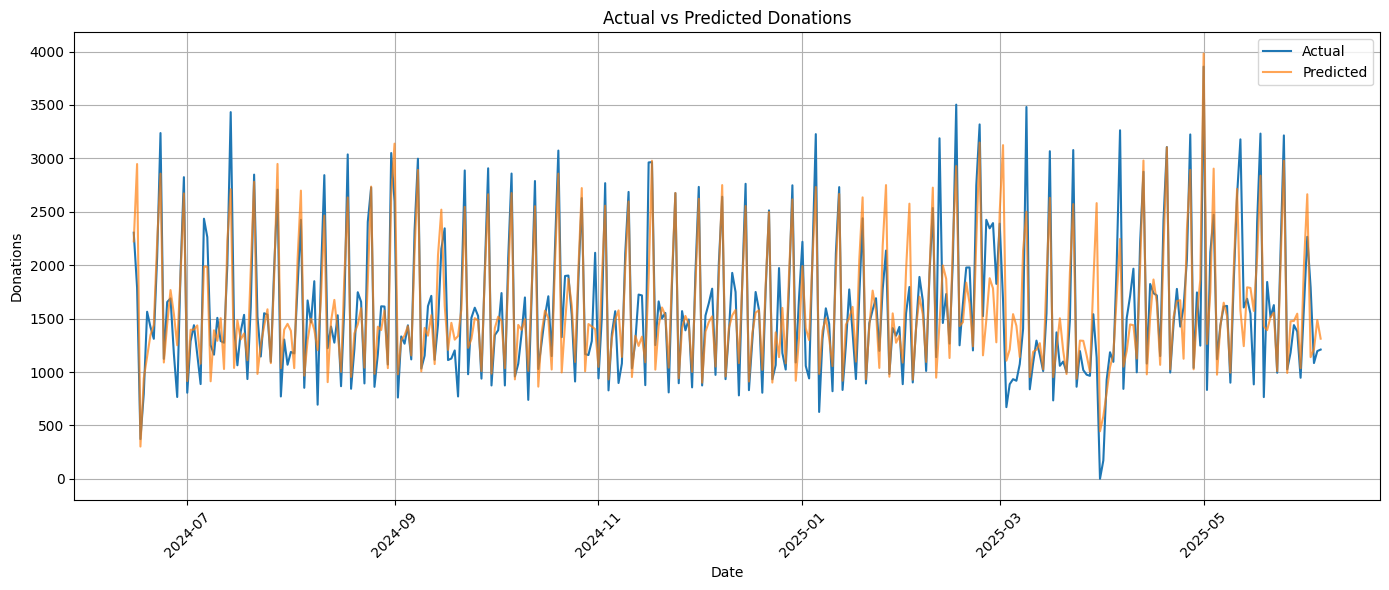

In [14]:
pred_df = pl.DataFrame({'y_true': y_test_scaled.flatten(), 'y_pred': np.round(y_pred).flatten()})

pred_df = pred_df.with_columns(
    (pl.col('y_true') - pl.col('y_pred')).alias('diff')
).with_columns(
    pl.Series("date", df_all[-pred_df.height:]["date"])
)

pred_df = pred_df.with_columns(
    (abs(pl.col('diff')).alias('abs_diff'))
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(pred_df["date"], pred_df["y_true"], label="Actual")
plt.plot(pred_df["date"], pred_df["y_pred"], label="Predicted", alpha=0.7)
plt.title("Actual vs Predicted Donations")
plt.xlabel("Date")
plt.ylabel("Donations")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
pred_df['y_true'].mean()

1609.508426966292

In [16]:
pred_df.sort(by='abs_diff', descending=True).head(10)

y_true,y_pred,diff,date,abs_diff
f64,f32,f64,date,f64
3188.0,1457.0,1731.0,2025-02-11,1731.0
3178.0,1578.0,1600.0,2025-05-12,1600.0
1674.0,3124.0,-1450.0,2025-03-02,1450.0
1136.0,2581.0,-1445.0,2025-03-30,1445.0
1789.0,2947.0,-1158.0,2024-06-16,1158.0
2962.0,1880.0,1082.0,2024-11-16,1082.0
3263.0,2246.0,1017.0,2025-04-06,1017.0
3481.0,2501.0,980.0,2025-03-09,980.0
2425.0,1488.0,937.0,2025-02-25,937.0


While all in all the model seems to be performing well, on certain days it still shows a bigger deviance:
- 2025-02-11: Thaipusam, which is not a national holiday but observed in eight states. Incorporating this can be valuable in the future
- 2025-03-30: The day before Hari Raya Puasa, while not a holiday itself can lead to lower level of donations (preparations etc)
- 2025-03-02: The first day of Ramadan, which also leads to lower actual donations than predicted

Some other days which should have been properly observed still showed some difference:
- 2025-05-12: Wesak Day
- 2024-09-16: Malaysia Day

Based on this it might make sense to extend the low donation holidays to 1 day before/after the actual date.

In [17]:
# Saving the model
model.save(f"shared/model_{experiment_name}.keras")

## Comparison with simple benchmarks

### Comparison with mean value from the validation set

In [18]:
# Comparison with mean value from validation set
mean_val = y_scaler.inverse_transform(y_val.reshape(-1, 1)).mean()

mean_pred = np.full_like(y_test_scaled, mean_val)
mean_absolute_error(y_test_scaled, mean_pred)

526.6097727417

### Comparison with rolling average

In [19]:
# Concatenate y_train, y_val, and y_test for easy indexing
y_all = np.concatenate([y_val, y_test])

# Indices for the start of y_test in y_all
test_start_idx = len(y_val)

# Rolling average prediction for y_test
rolling_preds = []
for i in range(test_start_idx, test_start_idx + len(y_test)):
    # Take the previous 7 days
    prev_7 = y_all[i-constants.WINDOW_SIZE:i]
    rolling_preds.append(prev_7.mean())

rolling_preds = np.array(rolling_preds)

mean_absolute_error(y_test, 
                    y_scaler.inverse_transform(rolling_preds[-len(y_test):].reshape(-1, 1))
)

1612.5542264429052

We could confirm that using the model is meaningfully better in terms of performance over simple benchmarks.